In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib
%matplotlib inline

In [12]:
df = pd.read_csv("C:/Users/Lenovo/Downloads/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [103]:
# We are obtaining the statistical properties ofthe numerical data
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### From the data we can see here that total 1338 data points
* for the age column Maximum person age is 64 years and minimum is 18years. 
* we can also see that the 75 percentile of the person has more than 51 years old
* The avearage age ofthe person is 39 years
* similarly other columns can also be explained

In [104]:
# Now find the column having mising data
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

* There is no missing value present in the dataset

In [105]:
sns.set_style("white")
matplotlib.rcParams['font.size']=14
matplotlib.rcParams['font.weight']='bold'
matplotlib.rcParams['figure.figsize']=(8,4)
matplotlib.rcParams['figure.facecolor']='#00000000'

In [106]:
fig= px.histogram(df,
                 x='age',
                 marginal = 'box',
                 nbins = 47,
                 title = 'Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

In [107]:
fig = px.histogram(df,
                  x='bmi',
                  marginal = 'box',
                  nbins = 47,
                  color_discrete_sequence = ['red'],
                  title = 'Distribution of BMI')
fig.update_layout(bargap = 0.1)
fig.show()

In [108]:
fig = px.histogram(df,
                  x= 'charges',
                  color = 'smoker',
                  color_discrete_sequence = ['gray', 'green'],
                  nbins = 47,
                  title = 'Distribution of charges between smoker and nonsmoker'
                  )
fig.update_layout(bargap = 0.1)
fig.show()

* From the figure it is clear that most of the person who dont smoke have low medical charges and only some persons have medical charges greater than 20K
* Most of the persons who smoke have higher medical charges and most of them have more than 20K annualmedical charges
* it is clear from figure that smoking habits is important parameter for on which medical charges depends 

In [109]:
#Now we find the number of people who smoke
df.smoker.value_counts()

no     1064
yes     274
Name: smoker, dtype: int64

* very less number of people has smoking habits

In [110]:
# We can see smokiing habits among gender
fig = px.histogram(df, x = 'smoker', color = 'sex', title = 'Distribution of smoker')
fig.show()

* Smoking habits are more among males

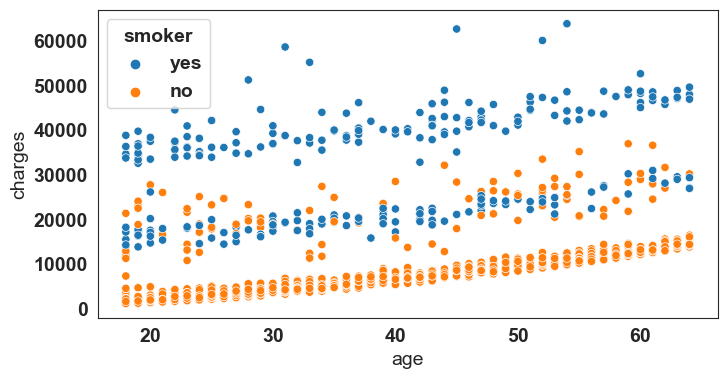

In [111]:
sns.scatterplot(data =df, x= 'age', y = 'charges',hue='smoker')
plt.show()

* from this plot we can clearly see that there are three clusters
* most of people have low medical charges who dont smoke and only some of them have high medical charges who does not smoke it may be due to other factors like bmi or children
* There is a linear relationship between age and charges

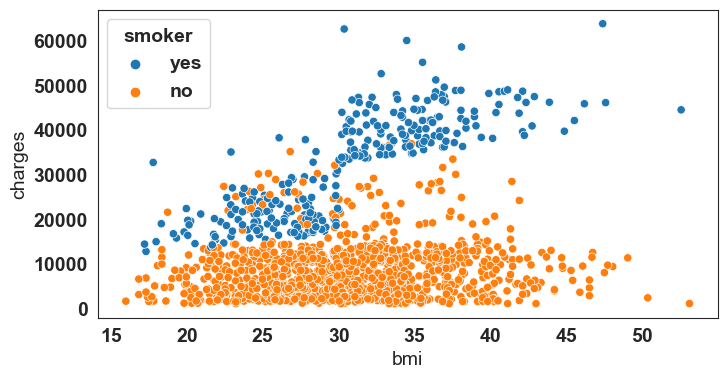

In [112]:
sns.scatterplot(data =df, x= 'bmi', y = 'charges',hue='smoker')
plt.show()

* There isno clear relations between charges and BMI
* There is high medical who has high BMI and smoking habits

In [113]:
#Now we find the correlation among the numerical columns
df.corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


* From Table it is clear that age is most important and children is low corelation coefficient

In [114]:
# Now develope the Linear regression model with numeric data
df_numeric = df[["age", "bmi","children", "charges"]]
df_numeric.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



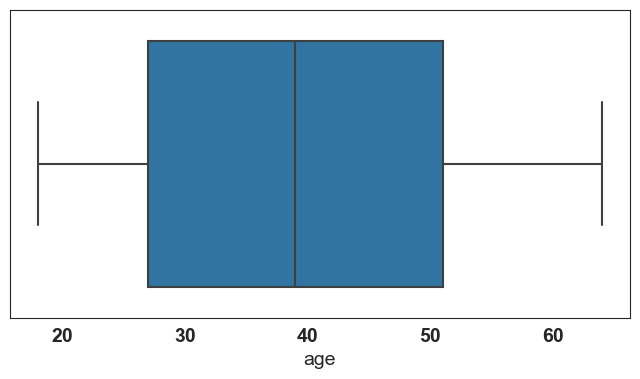

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



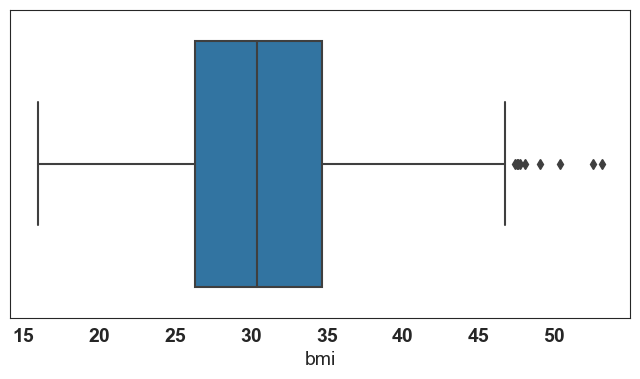

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



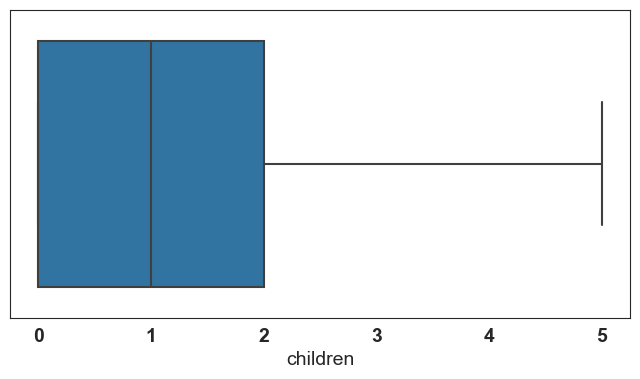

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



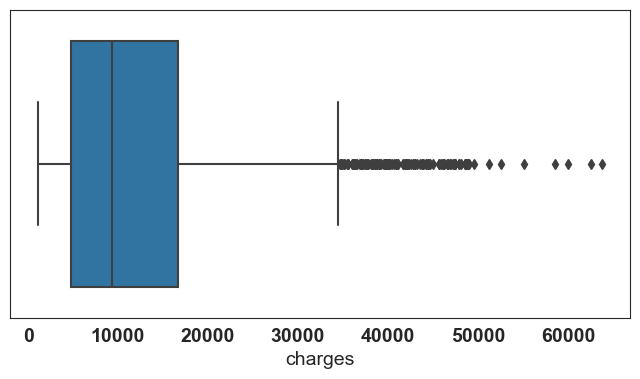

In [115]:
# Identify the outliers to the dataset
for i in df_numeric.columns:
    sns.boxplot(df_numeric[i])
    plt.show()

In [116]:
#Now standarise the df_numeric
from sklearn.preprocessing import StandardScaler
X = df_numeric[["age", "bmi", "children"]]
y= df_numeric["charges"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)

In [117]:
# Split the data into train test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
X_train,X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape
model= LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
R2_Score = r2_score(y_test,y_pred)
print("Mean Squared Error", MSE)
print(R2_Score)

Mean Squared Error 131201335.64669806
0.15489592484270753


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



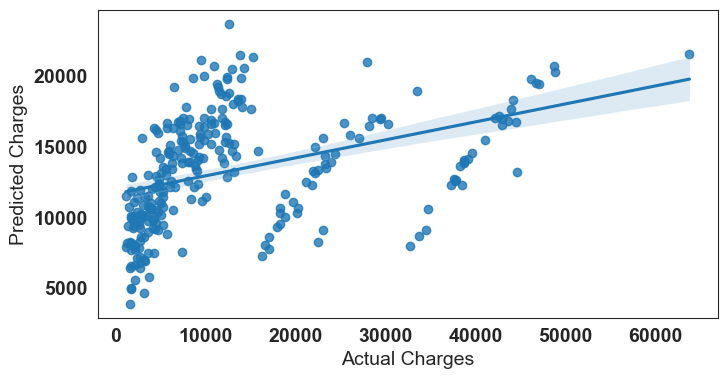

In [118]:
sns.regplot(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

* The linear model fitted here and tried to predict he medical charges based on test data
* In the above figure we can clearly see there are 3 cluster also afecting the prediction model
* model is not good because performance measured in form MSE and which is very high and R2 score low only 0.15
* the possible reason may be outliers present in the data set

In [119]:
# Decision Tree modeldevelopment
from sklearn.tree import DecisionTreeRegressor
model= DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
R2_Score = r2_score(y_test,y_pred)
print("Mean Squared Error", MSE)
print(R2_Score)

Mean Squared Error 301743720.8521811
-0.9436147268499273


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



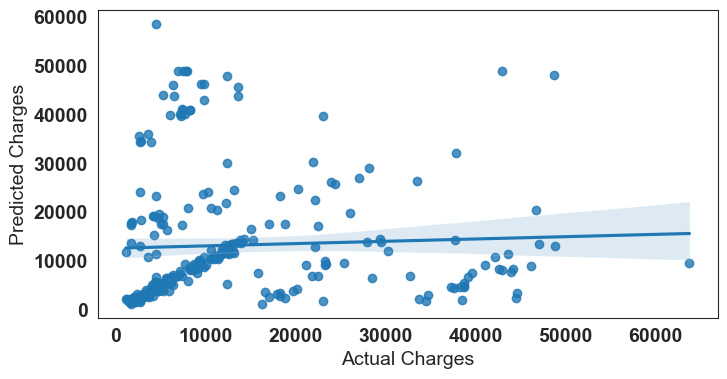

In [120]:
sns.regplot(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

* Decision tree clearly not working well and not able to predict 
* the posible reasons are 

Mean Squared Error 158498748.29147378
-0.020934256714828736


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



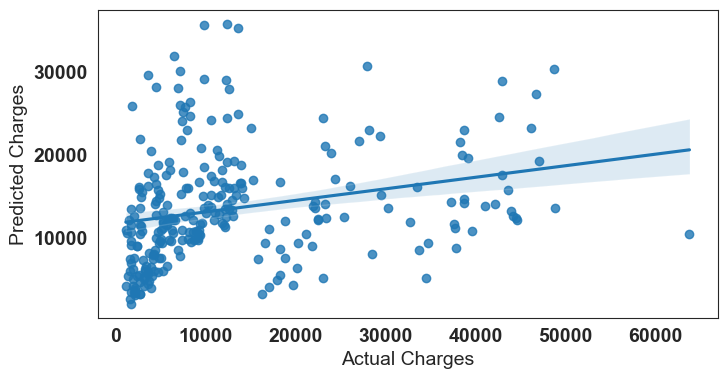

In [121]:
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
R2_Score = r2_score(y_test,y_pred)
print("Mean Squared Error", MSE)
print(R2_Score)
sns.regplot(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.show()

* Here Random Forest model is also not working Loss is high very high and R2 score also not good
* This model is not recommended

2️⃣ Important Predictors are Missing (Domain Issue)

Medical insurance charges cannot be explained well using only:

age

bmi

children

Key missing variables usually include:

smoker / non-smoker (most important)

sex

region

chronic conditions

👉 In the well-known medical cost dataset, smoking status dominates cost variation.
Without it, the tree creates incorrect splits, leading to large prediction errors.

📌 Result → worse than mean prediction → R² < 0

* Presence of Extreme Outliers in Medical Charges

Medical charges are highly right-skewed:

A few very expensive cases

Tree tries to fit them → bad splits

This increases variance dramatically.

In [122]:
# Now we included categorical features also and work on the complete data
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [123]:
# Map the smoker columns to 0 and 1 for Nonsmoking and smoking
smoker_value = {'no':0, 'yes':1}
df['smoker'] = df['smoker'].map(smoker_value)
sex_value = {'female':0, 'male':1}
df['sex'] = df['sex'].map(sex_value)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [124]:
numeric_cols = []
for i in df.columns:
    if df[i].dtype != 'object':
        numeric_cols.append(i)
numeric_cols

['age', 'sex', 'bmi', 'children', 'smoker', 'charges']

In [125]:
df2 = df[numeric_cols]
df2.head()

,age,sex,bmi,children,smoker,charges
0,19,0,27.900,0,1,16884.92400
1,18,1,33.770,1,0,1725.55230
2,28,1,33.000,3,0,4449.46200
3,33,1,22.705,0,0,21984.47061
4,32,1,28.880,0,0,3866.85520


In [126]:
df2.corr()

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


In [127]:
from sklearn.preprocessing import StandardScaler
x= df2.iloc[:,0:-1]
y=df2.iloc[:,-1]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled = pd.DataFrame(x_scaled, columns = x.columns)

In [128]:
# Split the data into input features and target variable 
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state= 42)
x_train.shape, y_train.shape

((1070, 5), (1070,))

In [129]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
R2_score = r2_score(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)
print(f"Mean squared error of the model is {mse} and R2 score {R2_score}")

Mean squared error of the model is 33979257.05080822 and R2 score 0.7054413633224745


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



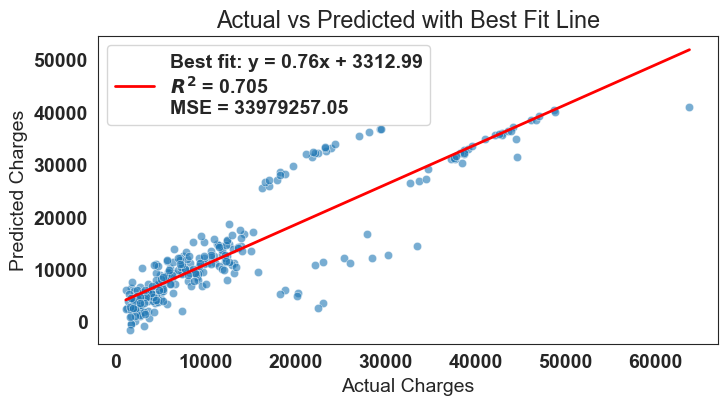

In [130]:
#Best fit line (y_test vs y_pred)
m, b = np.polyfit(y_test, y_pred, 1)
# plot the y_pred, and y_test
plt.figure(figsize = (8,4))
sns.scatterplot(y_test, y_pred, alpha=0.6)
#best fit line plot
x_vals = np.linspace(y_test.min(), y_test.max(), 100)

plt.plot(
    x_vals,
    m*x_vals + b,
    color='red',
    linewidth=2,
    label=(
        f"Best fit: y = {m:.2f}x + {b:.2f}\n"
        f"$R^2$ = {R2_score:.3f}\n"
        f"MSE = {mse:.2f}"
    )
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend(frameon=True)
plt.show()

MSE of the model is 41027945.55228385 and the R2score of the model is 0.7568971856194546


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



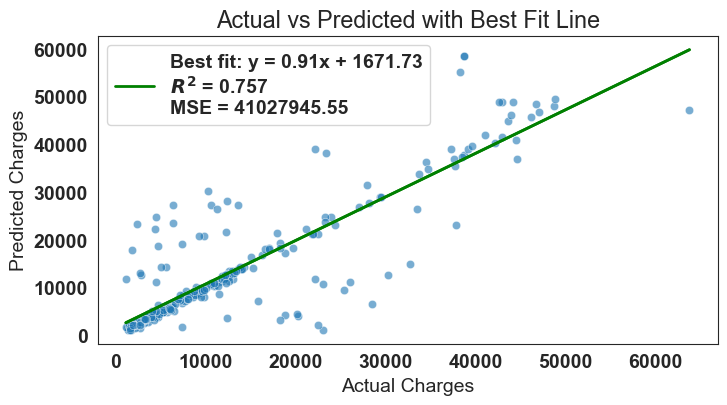

In [131]:
# Now try with Decision tree
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_pred, y_test)
R2_score = r2_score(y_pred, y_test)
print(f"MSE of the model is {mse} and the R2score of the model is {R2_score}")
#Best fit line (y_test vs y_pred)
m, b = np.polyfit(y_test, y_pred, 1)
# plot the y_pred, and y_test
plt.figure(figsize = (8,4))
sns.scatterplot(y_test, y_pred, alpha=0.6)
#best fit line plot
x_val = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_val, m*x_val+b, color = 'green', linewidth = 2)

plt.plot(
    x_vals,
    m*x_vals + b,
    color='green',
    linewidth=2,
    label=(
        f"Best fit: y = {m:.2f}x + {b:.2f}\n"
        f"$R^2$ = {R2_score:.3f}\n"
        f"MSE = {mse:.2f}"
    )
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend(frameon=True)
plt.show()

* Decision Tree works better than the Linear Regression model and R2 score value improved

MSE of the model is 21110289.868994128 and the R2 score of the model 0.8640227867490644


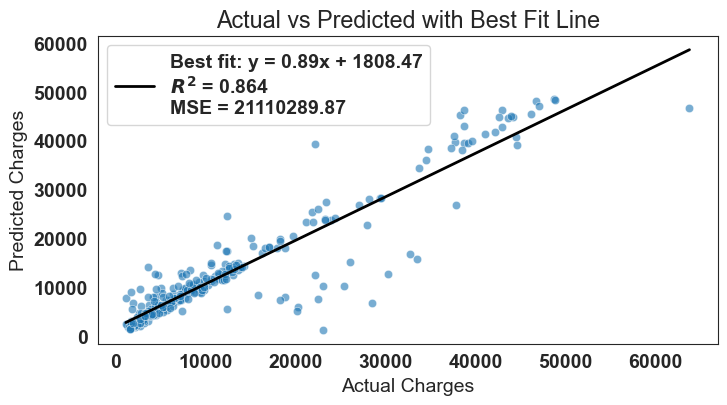

In [132]:
#Now try with Random forest regressor
model = RandomForestRegressor()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_pred, y_test)
R2_score = r2_score(y_test, y_pred)
print(f"MSE of the model is {mse} and the R2 score of the model {R2_score}")
# plot the best fit line
m, b = np.polyfit(y_test, y_pred, 1)
plt.figure(figsize = (8,4))
sns.scatterplot(x=y_test, y=y_pred, alpha = 0.6)
# Best fit line
x_val = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_val, m*x_val+b, color = 'black', linewidth = 2,
        label = (f"Best fit: y = {m:.2f}x + {b:.2f}\n"
        f"$R^2$ = {R2_score:.3f}\n"
        f"MSE = {mse:.2f}")
        )

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend(loc ='best')
plt.show()

* Randomforest gives best performance among all the models Lowest MSE and best R2 square

In [133]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse=False)

encoded = encoder.fit_transform(df[['region']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['region'])
)

df = pd.concat([df.drop('region', axis=1), encoded_df], axis=1)

In [134]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0.0,0.0,1.0
1,18,1,33.770,1,0,1725.55230,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,1.0,0.0,0.0


In [135]:
# Now try with removal of outliers
df.head()
for col in df.columns:
    q1 = df[col].quantile(0.25)
    q3= df[col].quantile(0.75)
    IQR = q3-q1
    df = df[(df[col]>=q1-1.5*IQR) & (df[col]<=q3+1.5*IQR)]

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



<AxesSubplot:xlabel='charges'>

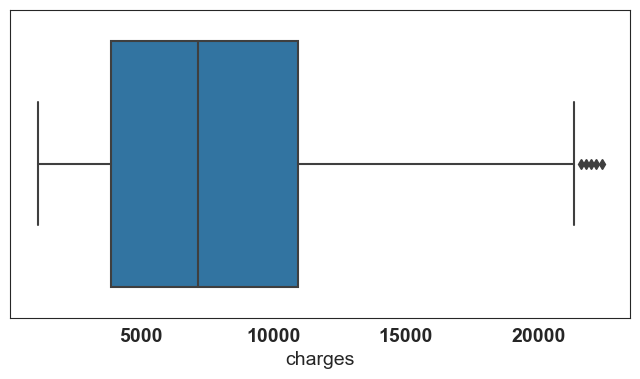

In [136]:
sns.boxplot(df['charges'])

* SO here outliers are removed from the columns

In [141]:
x= df.drop('charges', axis=1)

In [142]:
y= df['charges']

MSE of the model is 4281408.169196281 and the R2 score of the model 0.7211356366290835


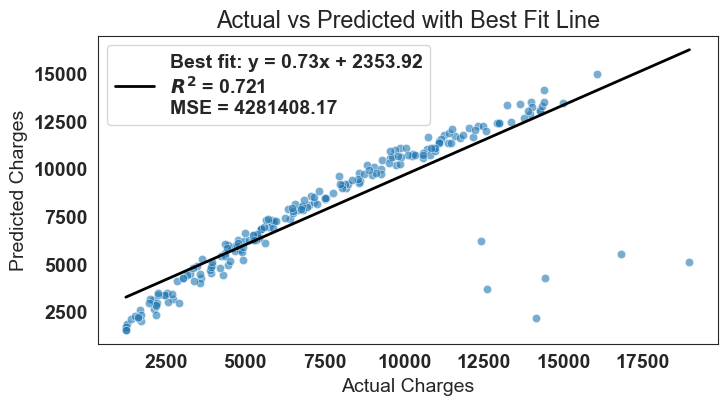

In [147]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_pred, y_test)
R2_score = r2_score(y_test, y_pred)
print(f"MSE of the model is {mse} and the R2 score of the model {R2_score}")
# plot the best fit line
m, b = np.polyfit(y_test, y_pred, 1)
plt.figure(figsize = (8,4))
sns.scatterplot(x=y_test, y=y_pred, alpha = 0.6)
# Best fit line
x_val = np.linspace(y_test.min(), y_test.max(), 100)
plt.plot(x_val, m*x_val+b, color = 'black', linewidth = 2,
        label = (f"Best fit: y = {m:.2f}x + {b:.2f}\n"
        f"$R^2$ = {R2_score:.3f}\n"
        f"MSE = {mse:.2f}")
        )

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted with Best Fit Line")
plt.legend(loc ='best')
plt.show()

In [146]:
df

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
1,18,1,33.770,1,0,1725.55230,0.0,1.0,0.0
2,28,1,33.000,3,0,4449.46200,0.0,1.0,0.0
3,33,1,22.705,0,0,21984.47061,1.0,0.0,0.0
4,32,1,28.880,0,0,3866.85520,1.0,0.0,0.0
5,31,0,25.740,0,0,3756.62160,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
1332,52,0,44.700,3,0,11411.68500,0.0,0.0,1.0
1333,50,1,30.970,3,0,10600.54830,1.0,0.0,0.0
1334,18,0,31.920,0,0,2205.98080,0.0,0.0,0.0
1335,18,0,36.850,0,0,1629.83350,0.0,1.0,0.0


In [31]:
def medical_charge_prediction():
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from sklearn.linear_model import LinearRegression
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from xgboost import XGBRegressor
    model_name = input("Enter model (lr/ dt/ rf /xgb ): ").lower()
    if model_name=="lr":
        model = LinearRegression()
        scale = True
    elif model_name == "dt":
        model = DecisionTreeRegressor(random_state =42)
        scale= False
    elif model_name=="rf":
        model = RandomForestRegressor()
        scale = False
    elif model_name == "xgb":
        model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        )
        scale = False
    else:
        raise ValueError("Invalid model name")
    df = pd.read_csv("C:/Users/Lenovo/Downloads/insurance.csv")
    #Convert the categorical columns into numerical value
    smoker_val = {'no':0, 'yes':1}
    df['smoker'] = df['smoker'].map(smoker_val)
    sex_val = {'female':0, 'male':1}
    df['sex'] = df['sex'].map(sex_val)
    #Convert the categorical region to the numeric
    encoder = OneHotEncoder(drop = 'first', sparse = False)
    encoded = encoder.fit_transform(df[['region']])
    encoded_df = pd.DataFrame(encoded, 
                              columns=encoder.get_feature_names_out(['region'])
                             )
    df = pd.concat([df.drop('region', axis=1), encoded_df], axis=1)
    #Break the data into features and Target variable 
    X = df.drop('charges', axis = 1)
    y= df['charges']
    # Apply train_test_split for split the data into training and test data
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
    # Scale the data using StandardScaler method
    if scale:
        scaler = StandardScaler()
        x_train = scaler.fit_transform(x_train)
        x_test = scaler.transform(x_test)
        
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_pred, y_test)
    R2_score = r2_score(y_test, y_pred)
    print(f"MSE of the model is {mse} and the R2 score of the model {R2_score}")
    # plot the best fit line
    m, b = np.polyfit(y_test, y_pred, 1)
    plt.figure(figsize = (8,4))
    sns.scatterplot(x=y_test, y=y_pred, alpha = 0.6)
    # Best fit line
    x_val = np.linspace(y_test.min(), y_test.max(), 100)
    plt.plot(x_val, m*x_val+b, color = 'black', linewidth = 2,
            label = (f"Best fit: y = {m:.2f}x + {b:.2f}\n"
            f"$R^2$ = {R2_score:.3f}\n"
            f"MSE = {mse:.2f}")
            )

    plt.xlabel("Actual Charges")
    plt.ylabel("Predicted Charges")
    plt.title("Actual vs Predicted with Best Fit Line")
    plt.legend(loc ='best')
    plt.show()

Enter model (lr/ dt/ rf /xgb ): lr
MSE of the model is 33596915.85136147 and the R2 score of the model 0.7835929767120723


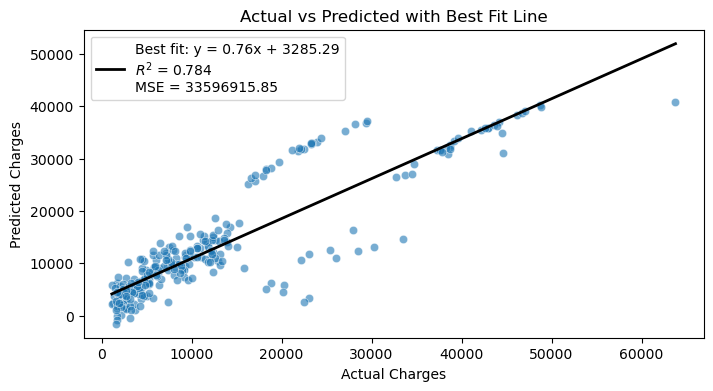

In [32]:
#model = LinearRegression()
medical_charge_prediction()

Enter model (lr/ dt/ rf /xgb ): dt
MSE of the model is 42446908.010150984 and the R2 score of the model 0.7265877305258355


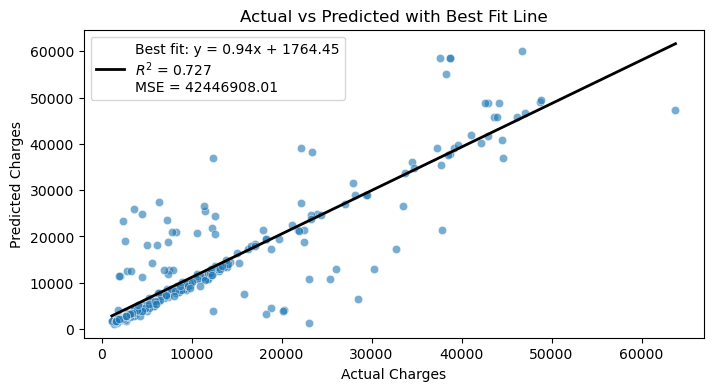

In [33]:
medical_charge_prediction()

Enter model (lr/ dt/ rf /xgb ): rf
MSE of the model is 21263078.898086827 and the R2 score of the model 0.8630386303722324


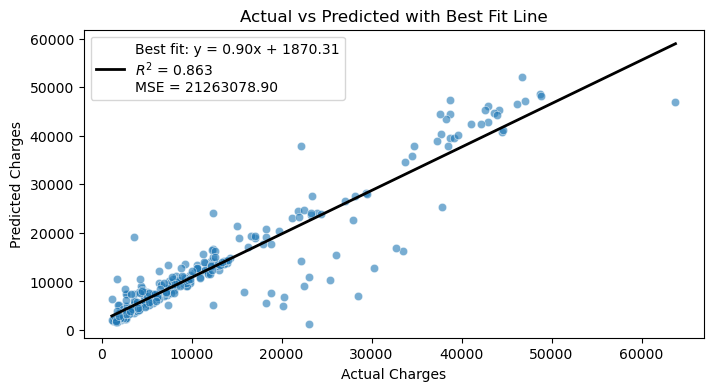

In [34]:
medical_charge_prediction()

Enter model (lr/ dt/ rf /xgb ): xgb
MSE of the model is 19356614.490300756 and the R2 score of the model 0.8753186946888101


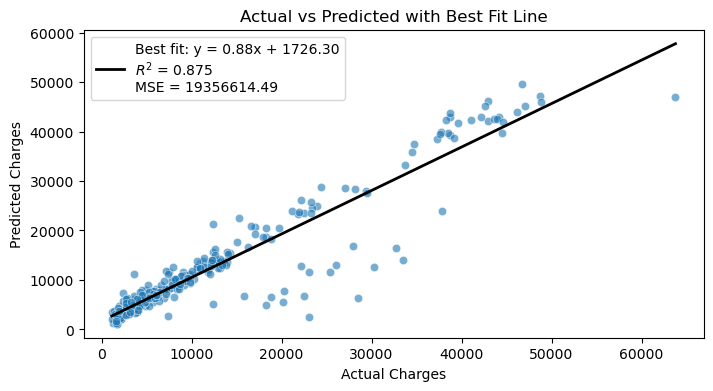

In [35]:
medical_charge_prediction()